# **Challenge 3 Telecom X - Parte 2**


Foco do Projeto:


Com base no Dataset tratado  na parte 1 do projeto (ETL). Construir modelos preditivos para identificar clientes com risco de evasão (churn)

Etapas:
## - Passo 1. Preparação dos Dados
## - Passo 2. Correlação de Variáveis
## - Passo 3. Modelo Preditivo
## - Passo 4. Interpretação
## - Passo 5. Conclusão e Relatório Final

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/content/dados_telecom_x_limpo.csv')

df.head()

,ID_Cliente,Evasao_Churn,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Valor_Mensal,Valor_Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Cliente            7267 non-null   object 
 1   Evasao_Churn          7267 non-null   int64  
 2   Genero                7267 non-null   object 
 3   Idoso                 7267 non-null   int64  
 4   Parceiro              7267 non-null   int64  
 5   Dependentes           7267 non-null   int64  
 6   Meses_Contrato        7267 non-null   int64  
 7   Servico_Telefone      7267 non-null   int64  
 8   Multiplas_Linhas      7267 non-null   int64  
 9   Servico_Internet      7267 non-null   object 
 10  Seguranca_Online      7267 non-null   int64  
 11  Backup_Online         7267 non-null   int64  
 12  Protecao_Dispositivo  7267 non-null   int64  
 13  Suporte_Tecnico       7267 non-null   int64  
 14  Streaming_TV          7267 non-null   int64  
 15  Streaming_Filmes     

## - Passo 1. Preparação dos Dados

In [12]:
# Transformação de Texto em números, como o Machine Learning só entende números, precisamos transformar as colunas object em numeric
# as colunas 'Genero', 'Servico_Internet', 'Tipo_Contrato' e 'Metodo_Pagamento'

# 1. Removendo o ID do Cliente (não é necessário na previsão - pois é apenas rótulo)
df_ml = df.drop(columns=['ID_Cliente'])

# 2. Transformando colunas de texto em colunas numéricas (Dummies)
# usamos drop_first=True para evitar redundância estatítica
df_ml = pd.get_dummies(df_ml, columns=['Genero', 'Servico_Internet', 'Tipo_Contrato', 'Metodo_Pagamento'], drop_first=True)

df_ml.head()


,Evasao_Churn,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,...,Valor_Mensal,Valor_Total,Genero_Male,Servico_Internet_Fiber optic,Servico_Internet_No,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,65.6,593.30,False,False,False,True,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,...,59.9,542.40,True,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,...,73.9,280.85,True,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,...,98.0,1237.85,True,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,...,83.9,267.40,False,True,False,False,False,False,False,True


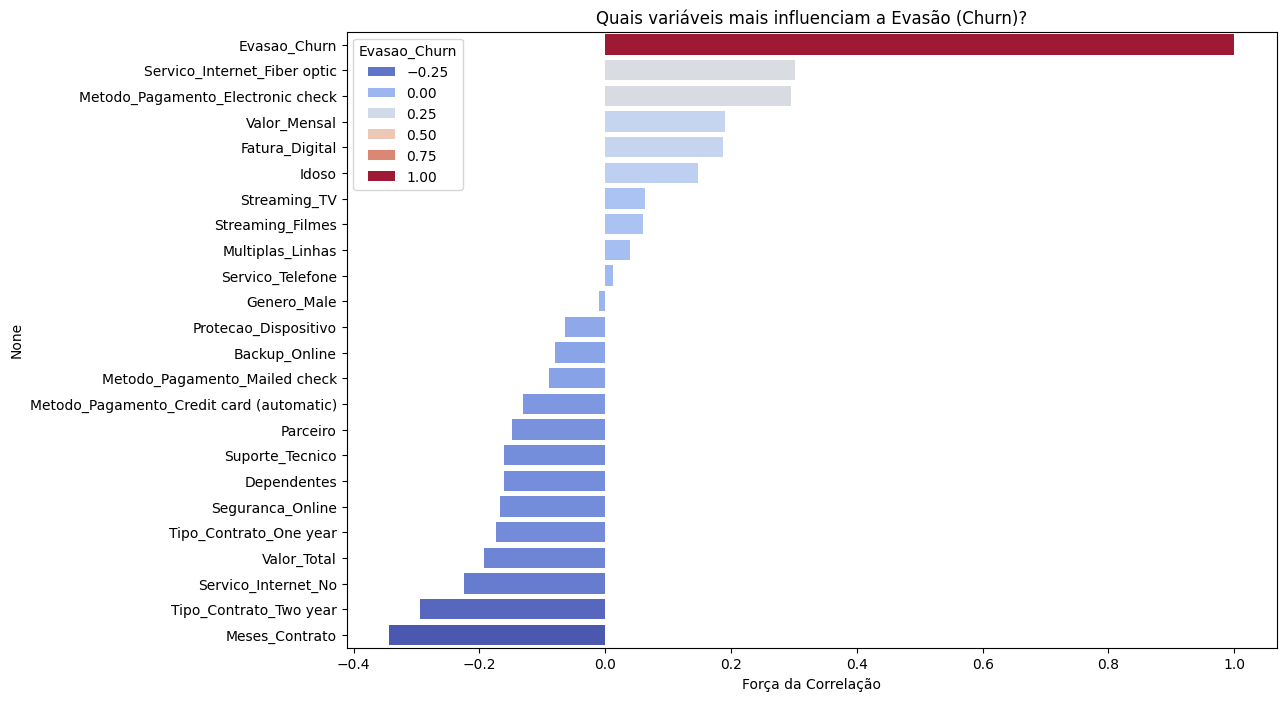

In [24]:
# Correlação de Variáveis - A 'Bússola'
# Antes de prever, vamos ver o que tira o cliente para fora da empresa
# Esse processo calcula a força da relação entre as variáveis.
# Próximos a 1 a correlação é forte, próximo a zero é fraca

plt.figure(figsize=(12, 8))
# Calculand a correlçaõ de todas variáveis com a coluna alvo (Evasao_Curn)
correlacao_churn = df_ml.corr()['Evasao_Churn'].sort_values(ascending=False)

#Protando o gráfico
sns.barplot(x=correlacao_churn.values, y=correlacao_churn.index, hue=correlacao_churn, palette='coolwarm')
plt.title('Quais variáveis mais influenciam a Evasão (Churn)?')
plt.xlabel('Força da Correlação')
plt.show()


In [22]:
# Modo Preditivo - Vamos ensinar a máquina
# Vamos usar a Random Forest (Floresta Aleatória), que cria centenas de "árvores de decisão" e combina as respostas para dar a preivisão mais precisa
# Esse processo separa os dados de treino (80% onde o modelo estuda) e testes (20% onde fazemos a prova final)
# Medimos pela Acurácia (quantos ele acertou o total) e pelo Recall (quantos dos clientes que realmente saíram ele conseguiu identificar)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Definindo X (tudo menos o Churn) e y (apenas o churn)
X = df_ml.drop('Evasao_Churn', axis=1)
y = df_ml['Evasao_Churn']

# Divindo os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Criando e treinando o modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Fazendo as previsões no conjunto de teste
y_pred = modelo_rf.predict(X_test)


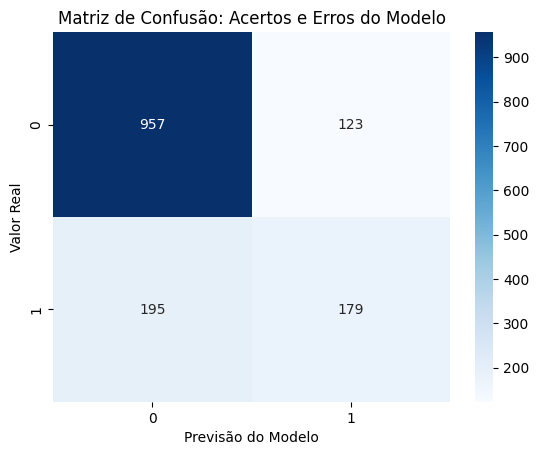

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1080
           1       0.59      0.48      0.53       374

    accuracy                           0.78      1454
   macro avg       0.71      0.68      0.69      1454
weighted avg       0.77      0.78      0.77      1454



In [23]:
# Interpretação e Conclusão (O Valor do Negócio)
# PAra iniciar, vamos pelo mais importante que é a Matriz de Confusão

#Criando a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão: Acertos e Erros do Modelo')

plt.show()
957

# Relatório detalhado
print(classification_report(y_test, y_pred))

# Primeiros Insights

**1º Correlação de Variáveis com o Churn**
Olhando para o gráfico de correlação de variáveis que mais empurram o liente para fora (correlação positiva alta) são:
1. **Servico_Internet_Fiver optic**: Clientes com fibra ótica estão saindo mais. Isso pode indicar um problema de preço ou instabilidade técnica nesse serviço específico
2. **Metodo_Pagamento_Electronic chech**: o uso de cheque eletrônico está fortemente ligado à evasão
3. **Valor_Mensal**: Quanto mais caro o plano, maior a chance de o cliente sair

Por outro lado, **Meses_Contrato** (tenure) e o **Tipo_Contrato_Two year** tÊm as maiores correlações negativas. isso confirma estatísticamente o que vismo no gráfico de densidade da parte 1 do trabalho: **tempo de casa e contratos longos são as melhores proteções contra o Churn.**


**2º Analisando a Matriz de Confusão e as Métricas**
A matriz nos mostra q ue o modelo é muto bom em identificar quem fica (957 acertos), mas ainda tem um desafio em capturar todos os que saem.
- **Acurácia (0.78)**: O modelo acerta 78% de todas as previsões. É um número sólido para um primeiro modelo.
- **Recall de Churn (0.48)**: Este é o ponto de atenção. O modelo consegue identificar 48% dos clientes que realmente cancelaram. Ou seja, ele deixa passar metade das evasões (195 eros no quadrate intferir esquerdo)
- **Precisão do Churn (0.59)**: Quando o modelo iz que alguém vai sair, ele está certo em 59% das vezes.


# Sugestões

1º **Recomendação de Negócio**: Sugiro que a Telecom X crie uma campanha de retenção agressiva para clientes de **Fibra Ótica** que pagam via **Cheque Eletrônico**, pois o modelo provou que este é o grupo de altíssimo risco.

2º **Análise de Risco Etário**: Na parte 1 do nosso trabalho de análise, a tabela de perfil etário provou que **Idosos com contratos mensais** têm **52,88%** de taxa de evasão. O modelo de Machine Learning apenas deu o carimbo matemático de confirmação de nossa descoberta inicial

# **Relatorio Final**

Análise Concluída: Os insights estratégicos sobre a retenção de clientes e as recomendações para redução de Churn detalhadas estão disponíveis no relatório final.

[Acessar Relatório Final (PDF)](https://github.com/vanrpontes/challenge3-telecom_x_parte2/blob/main/relatorio/Challenge-3_Telecom_X-Relatorio_Modelo_de_Previsao_de_Perdas_Financeiras.pdf)